# Customer Retention Analysis

## Loading and Preparing Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"D:\Projects\customer-retention-analysis\data\telco_churn_raw.csv")

In [3]:
# Check the DataFrame shape and columns
print(df.shape)
print(df.columns)

(7043, 21)
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')


In [4]:
# Check the data type of TotalCharges
df['TotalCharges'].dtype

<StringDtype(na_value=nan)>

In [5]:
# Use pd.to_numeric() to convert TotalCharges to numeric values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [6]:
# Use dropna() to remove rows with NaN values
df = df.dropna(subset=['TotalCharges'])

## Churn Rate by Contract Type

In [7]:
# Flag churned customers
df['Churn_Yes'] = (df['Churn'] == 'Yes')

In [8]:
# Use groupby() and agg() to calculate churn statistics by contract
df.groupby('Contract')['Churn_Yes'].agg(['sum', 'count', 'mean'])

,sum,count,mean
Contract,,,
Month-to-month,1655,3875,0.427097
One year,166,1472,0.112772
Two year,48,1685,0.028487


In [9]:
# Calculate churn rate percent for each contract type
contract_churn = df.groupby('Contract')['Churn_Yes'].mean() * 100

In [10]:
# Make all future figures 8 x 5 inches and remove border lines
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False})

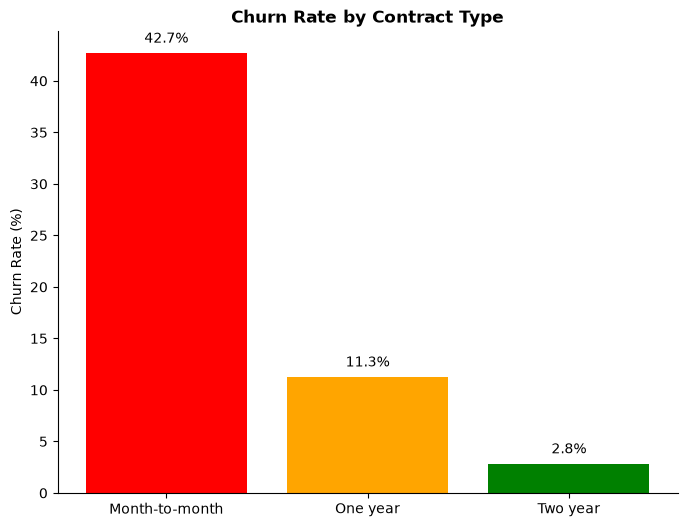

In [11]:
# Plot churn rates by contract type and label each bar
bars = plt.bar(contract_churn.index, contract_churn.values, color=['red', 'orange', 'green'])
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', ha='center')

plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Contract Type', fontweight='bold')
plt.savefig(r'D:\Projects\customer-retention-analysis\outputs\churn_by_contract.png', dpi=150)
plt.show()

## Churn Rate by Tenure Bucket

In [12]:
# Used pd.cut to divide tenure into defined month ranges
df['TenureBucket'] = pd.cut(df['tenure'], bins=[0, 6, 12, 24, 48, 72], labels=['0-6 months', '7-12 months', '13-24 months', '25-48 months', '49-72 months'])

In [13]:
# Use groupby() and mean() to calculate churn rate by tenure bucket
Tenure_Bucket = df.groupby('TenureBucket')['Churn_Yes'].mean() * 100

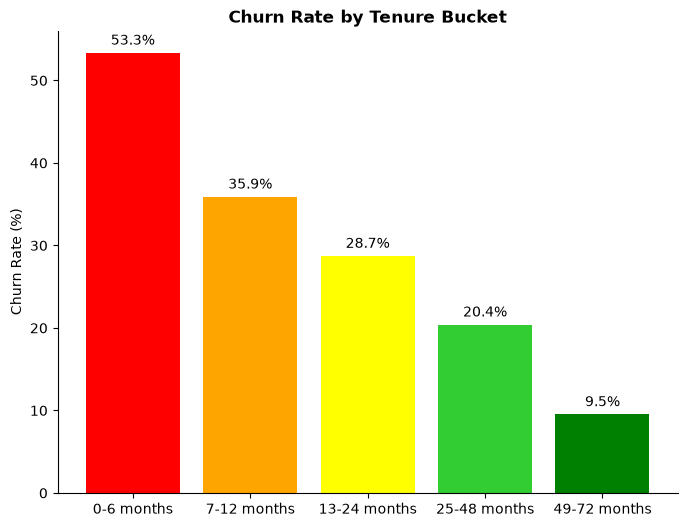

In [14]:
# Plot churn rates by tenure bucket and label each bar
bars = plt.bar(Tenure_Bucket.index, Tenure_Bucket.values, color=['red', 'orange', 'yellow', 'limegreen', 'green'])
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', ha='center')

plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Tenure Bucket', fontweight='bold')
plt.savefig(r'D:\Projects\customer-retention-analysis\outputs\churn_by_tenure.png', dpi=150)
plt.show()

## Revenue at Risk — Retained vs. Churned

In [15]:
# Filter customers by contract, payment method, and tenure
segment = df[(df['Contract'] == 'Month-to-month') & (df['PaymentMethod'] == 'Electronic check') & (df['tenure'] <= 12)]

In [16]:
# Calculate total monthly charges for retained and churned customers #fix it later
retained = df[df['Churn_Yes'] == False]['MonthlyCharges'].sum()
churned = df[df['Churn_Yes'] == True]['MonthlyCharges'].sum()

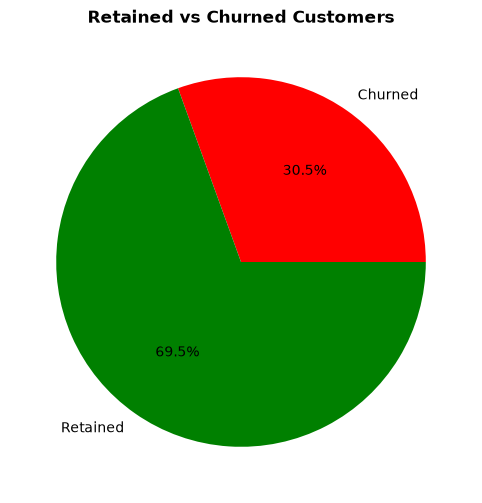

In [17]:
plt.pie([churned, retained], labels=['Churned', 'Retained'], autopct='%1.1f%%', colors=['red', 'green'])
plt.title('Retained vs Churned Customers', fontweight='bold')
plt.savefig(r'D:\Projects\customer-retention-analysis\outputs\revenue_at_risk.png', dpi=150)
plt.show()

## Rank Churned Customers by Monthly Charges

In [18]:
# Filter churned customers
churned = df[df['Churn'] == 'Yes']

In [19]:
# Rank monthly charges within each contract
churned['ContractRank'] = churned.groupby('Contract')['MonthlyCharges'].rank(ascending=False, method='min')
churned['OverallRank'] = churned['MonthlyCharges'].rank(ascending=False, method='min')

In [20]:
# Top 10 churned customers by revenue
Top_10 = churned.sort_values('MonthlyCharges', ascending=False).head(10)
Top_10[['OverallRank', 'customerID', 'Contract', 'MonthlyCharges', 'ContractRank']]

,OverallRank,customerID,Contract,MonthlyCharges,ContractRank
5127,1.0,8199-ZLLSA,One year,118.35,1.0
4610,2.0,2889-FPWRM,One year,117.80,2.0
4875,3.0,2302-ANTDP,Month-to-month,117.45,1.0
6289,4.0,9053-JZFKV,Two year,116.20,1.0
6537,5.0,1444-VVSGW,One year,115.65,3.0
1306,6.0,0201-OAMXR,One year,115.55,4.0
1077,7.0,4361-BKAXE,Month-to-month,114.50,2.0
6038,8.0,1555-DJEQW,Two year,114.20,2.0
1673,9.0,9158-VCTQB,Month-to-month,113.60,3.0
1770,10.0,7279-BUYWN,Month-to-month,113.20,4.0


In [21]:
# Max rank should match churned count per contract (1655/166/48)
churned.groupby('Contract')['ContractRank'].max()

Contract
Month-to-month    1655.0
One year           166.0
Two year            48.0
Name: ContractRank, dtype: float64